## Cleaning stage
- Plot graphs again and recalculate fatality rate. 
- Drop 2021 values.
- Drop irrelevant columns.
- Add adjusted damages.
- Make new datasets based on disaster type - drop features with too many missing values.

In [1]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt 

In [2]:
df = pd.read_csv('/Users/veron/Desktop/natural disasters project/data/raw/1970-2021_DISASTERS.xlsx - emdat data.csv')

In [3]:
df.head()

,Dis No,Year,Seq,Glide,Disaster Group,Disaster Subgroup,Disaster Type,Disaster Subtype,Disaster Subsubtype,Event Name,...,No Homeless,Total Affected,Reconstruction Costs ('000 US$),Insured Damages ('000 US$),Total Damages ('000 US$),CPI,Adm Level,Admin1 Code,Admin2 Code,Geo Locations
0,1970-0013-ARG,1970,13,NaN,Natural,Hydrological,Flood,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,25000.0,15.001282,NaN,NaN,NaN,NaN
1,1970-0109-AUS,1970,109,NaN,Natural,Meteorological,Storm,Tropical cyclone,NaN,Ada,...,NaN,NaN,NaN,NaN,72475.0,15.001282,NaN,NaN,NaN,NaN
2,1970-0044-BEN,1970,44,NaN,Natural,Hydrological,Flood,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,200.0,15.001282,NaN,NaN,NaN,NaN
3,1970-0063-BGD,1970,63,NaN,Natural,Meteorological,Storm,Tropical cyclone,NaN,NaN,...,NaN,3648000.0,NaN,NaN,86400.0,15.001282,NaN,NaN,NaN,NaN
4,1970-0026-BGD,1970,26,NaN,Natural,Meteorological,Storm,NaN,NaN,NaN,...,NaN,110.0,NaN,NaN,NaN,15.001282,NaN,NaN,NaN,NaN


### Dropping irrelevant columns.

In [4]:
df = df.drop(columns=['Dis No', 'Seq', 'Glide', 'Disaster Subsubtype', 'Event Name', 'ISO', 'Location', 'Origin', 'Associated Dis', 'Associated Dis2', 'Latitude', 'Longitude', 'Local Time', 'River Basin', 
'No Injured', 'No Affected', 'No Homeless', "Reconstruction Costs ('000 US$)", "Insured Damages ('000 US$)", 'Admin1 Code', 'Admin2 Code', 'Geo Locations', 'Appeal', 'Declaration', 'Adm Level'])

### Dropping rows that were recorded in 2021.

In [5]:
df = df[df['Year'] <= 2020]

In [6]:
df.head()

,Year,Disaster Group,Disaster Subgroup,Disaster Type,Disaster Subtype,Country,Region,Continent,OFDA Response,Aid Contribution,...,Start Year,Start Month,Start Day,End Year,End Month,End Day,Total Deaths,Total Affected,Total Damages ('000 US$),CPI
0,1970,Natural,Hydrological,Flood,NaN,Argentina,South America,Americas,NaN,NaN,...,1970,1.0,4.0,1970,1.0,4.0,36.0,NaN,25000.0,15.001282
1,1970,Natural,Meteorological,Storm,Tropical cyclone,Australia,Australia and New Zealand,Oceania,NaN,NaN,...,1970,1.0,NaN,1970,1.0,NaN,13.0,NaN,72475.0,15.001282
2,1970,Natural,Hydrological,Flood,NaN,Benin,Western Africa,Africa,Yes,NaN,...,1970,9.0,NaN,1970,9.0,NaN,NaN,NaN,200.0,15.001282
3,1970,Natural,Meteorological,Storm,Tropical cyclone,Bangladesh,Southern Asia,Asia,Yes,NaN,...,1970,11.0,12.0,1970,11.0,12.0,300000.0,3648000.0,86400.0,15.001282
4,1970,Natural,Meteorological,Storm,NaN,Bangladesh,Southern Asia,Asia,NaN,NaN,...,1970,4.0,13.0,1970,4.0,13.0,17.0,110.0,NaN,15.001282


### Impute stage.

In [7]:
#df['Total Affected'] = df.groupby('Disaster Type')['Total Affected'].transform(lambda x: x.fillna(x.median()))
#df['Total Deaths'] = df.groupby('Disaster Type')['Total Deaths'].transform(lambda x: x.fillna(x.median()))


In [8]:
#df['Fatality Rate'] = df['Total Deaths'] / df['Total Affected']
#df['Fatality Rate']

In [9]:
#df['Fatality Rate'].plot(kind='hist', bins=50, title='Fatality Rate Distribution')

In [10]:
#df.isna().sum()

## PUT THIS IN EDA
### Drought and epidemic natural disasters have longer durations. 

In [11]:
print((df['End Year'] - df['Start Year'] > 1).sum())
print((df['End Month'] - df['Start Month'] > 1).sum())
print((df['End Day'] - df['Start Day'] > 1).sum())

92
755
3507


In [12]:
df.loc[df['End Year'] - df['Start Year'] > 1, ['Disaster Type', 'Start Year', 'End Year']].value_counts()

Disaster Type  Start Year  End Year
Drought        2015        2017        7
               1983        1985        5
               1980        1985        5
               1981        1983        4
               1999        2001        4
               1982        1985        3
               2000        2002        3
Epidemic       2005        2007        3
Drought        1979        1982        2
               1980        1983        2
               1981        1985        2
               1982        1984        2
               1992        1995        2
               1990        1995        2
               1999        2003        2
                           2002        2
               2001        2004        2
                           2003        2
               2007        2009        2
               2014        2016        2
Epidemic       2014        2016        2
Drought        1971        1973        1
               1973        1978        1
               1977  

In [13]:
df.loc[df['End Month'] - df['Start Month'] > 1, ['Disaster Type', 'Start Month', 'End Month']].value_counts()

Disaster Type       Start Month  End Month
Epidemic            1.0          3.0          29
                                 4.0          27
Flood               8.0          10.0         24
                    1.0          3.0          23
Epidemic            1.0          5.0          23
                                              ..
Drought             2.0          10.0          1
Wildfire            2.0          9.0           1
                    1.0          9.0           1
Insect infestation  1.0          5.0           1
Flood               7.0          12.0          1
Name: count, Length: 164, dtype: int64

In [14]:
df.loc[df['End Day'] - df['Start Day'] > 1, ['Disaster Type', 'Start Day', 'End Day']].value_counts()

Disaster Type  Start Day  End Day
Flood          14.0       16.0       27
Storm          2.0        4.0        25
Flood          1.0        8.0        24
Storm          25.0       27.0       23
Flood          26.0       28.0       21
                                     ..
Wildfire       10.0       17.0        1
               26.0       31.0        1
Storm          2.0        10.0        1
               11.0       18.0        1
               24.0       30.0        1
Name: count, Length: 985, dtype: int64

In [15]:
cols = ['Start Year', 'End Year', 'Start Month', 'End Month', 'Start Day', 'End Day']
df[cols].describe()

,Start Year,End Year,Start Month,End Month,Start Day,End Day
count,14329.000000,14329.000000,14063.000000,13780.000000,11279.000000,11350.000000
mean,2001.179985,2001.230512,6.443504,6.578520,15.221474,15.783172
std,12.335005,12.338322,3.403931,3.361152,8.968026,8.875567
min,1970.000000,1970.000000,1.000000,1.000000,1.000000,1.000000
25%,1993.000000,1993.000000,4.000000,4.000000,7.000000,8.000000
50%,2003.000000,2003.000000,7.000000,7.000000,15.000000,16.000000
75%,2011.000000,2011.000000,9.000000,9.000000,23.000000,24.000000
max,2021.000000,2021.000000,12.000000,12.000000,31.000000,31.000000


In [16]:
df['start_date'] = pd.to_datetime(dict(year=df['Start Year'], month=df['Start Month'], day=df['Start Day']), errors='coerce')
df['end_date'] = pd.to_datetime(dict(year=df['End Year'], month=df['End Month'], day=df['End Day']), errors='coerce')

df['duration_days'] = (df['end_date'] - df['start_date']).dt.days

In [17]:
df['duration_days']

0         0.0
1         NaN
2         NaN
3         0.0
4         0.0
         ... 
14586    32.0
14587     NaN
14588     6.0
14589     0.0
14590     NaN
Name: duration_days, Length: 14329, dtype: float64

### Line plot of duration of natural disasters

Text(0.5, 0, 'Duration (days)')

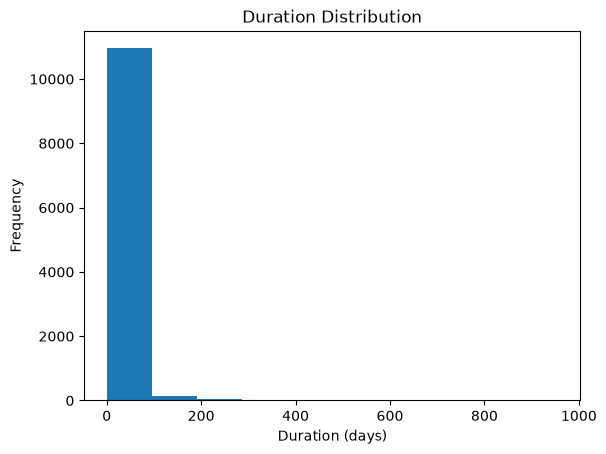

In [18]:
df['duration_days'].plot(kind='hist', title='Duration Distribution', x='Duration (days)')
plt.xlabel("Duration (days)")


In [19]:
df.isna().sum()

Year                            0
Disaster Group                  0
Disaster Subgroup               0
Disaster Type                   0
Disaster Subtype             2615
Country                         0
Region                          0
Continent                       0
OFDA Response               12879
Aid Contribution            13652
Dis Mag Value                9808
Dis Mag Scale                1053
Start Year                      0
Start Month                   266
Start Day                    3050
End Year                        0
End Month                     549
End Day                      2979
Total Deaths                 4321
Total Affected               3558
Total Damages ('000 US$)     9546
CPI                             0
start_date                   3052
end_date                     2984
duration_days                3159
dtype: int64

### Fill missing OFDA Response values as 'no'
### Drop appeal/declaration

In [20]:
df['OFDA Response'].fillna('No', inplace=True)
# This is because OFDA Response only has one non null value, which is 'Yes'. So we can assume that if the value is null, it means there was no OFDA Response.

/var/folders/ds/dw3yxr3n17zcdr5tkgbclc5w0000gn/T/ipykernel_31304/4221566451.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['OFDA Response'].fillna('No', inplace=True)


0         No
1         No
2        Yes
3        Yes
4         No
        ... 
14586     No
14587     No
14588     No
14589     No
14590     No
Name: OFDA Response, Length: 14329, dtype: str

## Use reference cpi to adjust damages column

In [21]:
reference_cpi = df.loc[df['Year'] == df['Year'].max()-1, 'CPI'].mean()

df['damages_adjusted'] = df["Total Damages ('000 US$)"] * (reference_cpi / df['CPI'])

## Grouping dis mag value by disaster type
### --> Initially checked missing rate for Dis Mag Value by disaster type, decided to check all other features of interest.

In [22]:
#dis_mag_value_missing_rate_by_disaster = df.groupby('Disaster Type')['Dis Mag Value'].apply(lambda x: x.isna().sum() / len(x))
#dis_mag_value_missing_rate_by_disaster

missing_rate_by_disaster = df.groupby('Disaster Type').apply(lambda x: x.isna().mean())
missing_rate_by_disaster=missing_rate_by_disaster[['Dis Mag Value', 'Region', 'Continent', 'Dis Mag Scale', 'Total Deaths',
 'Total Affected', "Total Damages ('000 US$)", 'damages_adjusted', 'duration_days', 'CPI']]
missing_rate_by_disaster 

,Dis Mag Value,Region,Continent,Dis Mag Scale,Total Deaths,Total Affected,Total Damages ('000 US$),damages_adjusted,duration_days,CPI
Disaster Type,,,,,,,,,,
Animal accident,1.000000,0.0,0.0,1.0,0.000000,0.000000,1.000000,1.000000,0.000000,0.0
Drought,0.924444,0.0,0.0,0.0,0.921481,0.330370,0.718519,0.718519,0.988148,0.0
Earthquake,0.022361,0.0,0.0,0.0,0.311270,0.071556,0.574240,0.574240,0.000000,0.0
Epidemic,0.965059,0.0,0.0,0.0,0.152341,0.122292,1.000000,1.000000,0.543676,0.0
Extreme temperature,0.527491,0.0,0.0,0.0,0.192440,0.689003,0.890034,0.890034,0.494845,0.0
Flood,0.653365,0.0,0.0,0.0,0.273865,0.145540,0.664124,0.664124,0.157473,0.0
Impact,1.000000,0.0,0.0,1.0,1.000000,0.000000,0.000000,0.000000,0.000000,0.0
Insect infestation,0.881720,0.0,0.0,1.0,1.000000,0.956989,0.946237,0.946237,0.903226,0.0
Landslide,0.987198,0.0,0.0,1.0,0.049787,0.406828,0.879090,0.879090,0.095306,0.0


### BY DISASTER TYPE
- Earthquake: Keep all features, calculate fatality rate
- Extreme temperature: dis mag value, total deaths, duration_days (may impute)
- Flood: total damages (may impute), total deaths, total affected, damages adjusted, duration_days
- Storm: total damages, damages_adjusted, duration_days, calculate fatality rate
- wildfire: dis mag value, total deaths (impute), total affected (impute), duration_days, calculate fatality rate 

In [23]:
df.groupby('Disaster Type')['Dis Mag Scale'].value_counts()

Disaster Type         Dis Mag Scale
Drought               Km2               675
Earthquake            Richter          1118
Epidemic              Vaccinated       1431
Extreme temperature   °C                582
Flood                 Km2              5112
Storm                 Kph              3922
Wildfire              Km2               436
Name: count, dtype: int64

In [24]:
features_earthquake = ['Dis Mag Value', 'Total Deaths', 'Total Affected', "Total Damages ('000 US$)", 'damages_adjusted', 'duration_days']
features_extreme_temp = ['Dis Mag Value','Total Deaths', 'duration_days']
features_flood = ['Total Deaths', 'Total Affected', "Total Damages ('000 US$)", 'damages_adjusted', 'duration_days']
features_storm = ['Total Deaths', 'Total Affected', "Total Damages ('000 US$)", 'damages_adjusted', 'duration_days']
features_wildfire = ['Dis Mag Value', 'Total Deaths', 'Total Affected', 'duration_days']

df_earthquake = df[df['Disaster Type'] == 'Earthquake'][features_earthquake].copy()
df_extreme_temp = df[df['Disaster Type'] == 'Extreme temperature'][features_extreme_temp].copy()
df_flood = df[df['Disaster Type'] == 'Flood'][features_flood].copy()
df_storm = df[df['Disaster Type'] == 'Storm'][features_storm].copy()
df_wildfire = df[df['Disaster Type'] == 'Wildfire'][features_wildfire].copy()

In [32]:
df_earthquake.to_csv(r'C:\Users\veron\Desktop\natural disasters project\data\processed\earthquake.csv', index=False)
df_extreme_temp.to_csv(r'C:\Users\veron\Desktop\natural disasters project\data\processed\extreme_temp.csv', index=False)
df_flood.to_csv(r'C:\Users\veron\Desktop\natural disasters project\data\processed\flood.csv', index=False)
df_storm.to_csv(r'C:\Users\veron\Desktop\natural disasters project\data\processed\storm.csv', index=False)
df_wildfire.to_csv(r'C:\Users\veron\Desktop\natural disasters project\data\processed\wildfire.csv', index=False)

In [25]:
df['Disaster Type'].value_counts()[['Impact', 'Mass movement (dry)', 'Insect infestation', 'Animal accident']]

Disaster Type
Impact                  1
Mass movement (dry)    41
Insect infestation     93
Animal accident         1
Name: count, dtype: int64

In [26]:
df_earthquake

,Dis Mag Value,Total Deaths,Total Affected,Total Damages ('000 US$),damages_adjusted,duration_days
13,7.0,10000.0,NaN,NaN,NaN,0.0
16,7.0,NaN,3006.0,400.0,2.633947e+03,0.0
25,7.0,29.0,88112.0,4000.0,2.633947e+04,0.0
38,5.0,26.0,200.0,NaN,NaN,0.0
39,8.0,85.0,2348973.0,236400.0,1.492589e+06,0.0
...,...,...,...,...,...,...
14301,5.0,NaN,278.0,NaN,NaN,0.0
14302,7.0,115.0,6034.0,450000.0,4.445165e+05,0.0
14491,6.0,NaN,NaN,1000.0,5.758052e+03,0.0
14492,7.0,NaN,11.0,5750.0,3.310880e+04,0.0


In [27]:
#target_disasters = ['Extreme temperature', 'Wildfire']

#mask = df['Disaster Type'].isin(target_disasters)

#df.loc[mask, 'Dis Mag Value'] = df.loc[mask, 'Dis Mag Value'].fillna(
   #df[mask].groupby('Disaster Type')['Dis Mag Value'].transform('mean')
#)


In [28]:
#df.groupby('Disaster Type')['Dis Mag Value'].apply(lambda x: x.isna().sum())

In [29]:
pd.set_option('display.max_columns', None)

In [30]:
#df.groupby('Disaster Type')[df.columns].apply(lambda x: x.isna().sum())